## Notebook for Soft MoE implementation  

In [1]:
## Imports
import time

import numpy as np 

import torch
from torch import nn
import torch.nn.functional as F
from torchvision.models.feature_extraction import create_feature_extractor, get_graph_node_names

In [2]:
## Set-up

# setting folder
DATA_DIR = "../../data"

# setting device
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", DEVICE)

Using device: cuda


## 1. Load and set-up data

In [3]:
from scripts.data import load_data

In [4]:
## Load data
train_dataset, test_dataset = load_data(DATA_DIR)

## Print info about dataset
print(f"Number of training samples: {len(train_dataset)}")
print(f"Number of test samples: {len(test_dataset)}")

first_image, first_label = train_dataset[0]
print(f"Shape of the first image: {first_image.shape}")
print(f"Label of the first image: {first_label}")

Number of training samples: 60000
Number of test samples: 10000
Shape of the first image: torch.Size([784])
Label of the first image: 5


In [5]:
## Making data loaders
BATCH_SIZE = 256
train_loader = torch.utils.data.DataLoader(dataset=train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_dataset_size = test_dataset.data.shape[0]
test_loader = torch.utils.data.DataLoader(dataset=test_dataset, batch_size=test_dataset_size, shuffle=True)

## 2. Set-up MoE model

In [6]:
class OneLayerExpert(torch.nn.Module):
    """Simple expert with only one hidden layer"""
    def __init__(self, input_size, hidden_size, output_size):
        super().__init__()
        # Hidden layer
        self.l_1 = torch.nn.Linear(input_size, hidden_size)
        self.relu_1 = torch.nn.ReLU()
        
        self.output = torch.nn.Linear(hidden_size, output_size)
    
    def forward(self, x):
        x = self.relu_1(self.l_1(x))
        x = self.output(x)
        return x

class Gating(torch.nn.Module):
    def __init__(self, input_size, hidden_size, output_size, topk=2):
        super().__init__()
        #here we have a sparse layer trainable weight
        self.l_sparse = torch.nn.Linear(input_size, output_size)
        #here is a noise trainable weight
        self.l_noise = torch.nn.Linear(input_size, output_size)
        self.softplus_noise = torch.nn.Softplus()
        self.topk = topk

    def forward(self, x):
        #will be of shape batch size x num_experts
        sparsity = self.l_sparse(x)
        noise = self.softplus_noise(self.l_noise(x))
        # print("Noise shape:", noise.shape)
        # print("Sparsity shape:", sparsity.shape)
        # print("noise: ", noise)
        normal_noise  = torch.normal(mean=torch.zeros_like(noise), std=1).to(DEVICE)
        # print("normal noise shape:", normal_noise.shape)
        # print("normal noise: ", normal_noise)
        noise = normal_noise * noise
        # print("noisy shape:", noise.shape)
        # print("noisy: ", noise)
        x = sparsity + noise
        # print("x shape:", x.shape)  
        # print("x: ", x)
        x = F.softmax(x, dim=-1) 
        return x

class SoftMOE(torch.nn.Module):
    def __init__(self, input_size, hidden_size_experts, hidden_size_gating, num_experts, output_size):
        super().__init__()
        # Creating gating layer
        self.gate = Gating(
            input_size = input_size, 
            hidden_size = hidden_size_gating, 
            output_size = num_experts
        )
        # Create experts
        self.experts = nn.ModuleList(
            [OneLayerExpert(
                input_size=input_size, 
                hidden_size = hidden_size_experts, 
                output_size = output_size
            ) for _ in range(num_experts)]
        )

    def forward(self, x):
        # if B = batch_size, N = expert_num, D_out = expert output dimension
        gating_output = self.gate(x) # shape: (B, N)
        #this follows the importance loss from the paper
        importance = gating_output.sum(0) # shape: (N,)
        # print("importance: ", importance)
        mean = torch.mean(importance)
        std_dev = torch.std(importance)
        cv = std_dev / mean
        loss_importance = 0.1 * cv * cv
        # print("Importance loss: ", loss_importance.item())
        expert_outputs = torch.stack([expert(x) for expert in self.experts], dim=2) # shape: (B, D_out, N)
        
        # Calculating weighted sum:
        # 1. gating_output.unsqueeze -> (B, N, 1)
        # 2. torch.bmm(...) -> (B, D_out, 1)
        # 3. .squeeze(2) -> (B, D_out)
        output = torch.bmm(expert_outputs, gating_output.unsqueeze(2)).squeeze(2)
        
        return output, gating_output, loss_importance

## 3. Training

### 3.1 Set-up

In [7]:
from scripts.training import training_loop

In [8]:
LEARNING_RATE = 0.0001
EPOCHS = 2

EXPERT_NUM = 8
MNIST_LINEAR_LENGTH = 784  # Input
MNIST_CLASS_NUM = 10       # Output
EXPERT_HIDDEN_SIZE = 25
GATING_HIDDEN_SIZE = 10

moe = SoftMOE(
    input_size=MNIST_LINEAR_LENGTH,
    hidden_size_experts=EXPERT_HIDDEN_SIZE,
    hidden_size_gating=GATING_HIDDEN_SIZE,
    num_experts=EXPERT_NUM,
    output_size=MNIST_CLASS_NUM
)

loss_function = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(moe.parameters(), lr=LEARNING_RATE)

### 3.2 Training

In [9]:
training_start = time.time()

training_loss, training_accuracy, test_loss, test_accuracy, expert_utilization_history = \
    training_loop(
        train_loader=train_loader, 
        test_loader=test_loader, 
        num_epochs=EPOCHS, 
        model=moe, 
        loss_function=loss_function, 
        optimizer=optimizer,
        device=DEVICE)

training_end = time.time()
training_duration = training_end-training_start

Starting the Training Loop


100%|██████████| 2/2 [00:12<00:00,  6.10s/it]


### 3.3 Plots

In [10]:
# If this import doesn't work, use: "pip install -e ." in root directory, and restart jupyter server.
from scripts import visualization

In [12]:
visualization.plot_training_curve(
    title="One Layer MoE accuracy and loss", 
    train_costs=training_loss, 
    test_costs=test_loss, 
    train_accuracy=training_accuracy, 
    test_accuracy=test_accuracy, 
    batch_size=BATCH_SIZE, 
    learning_rate=LEARNING_RATE, 
    training_time=training_duration, 
    epochs=EPOCHS)

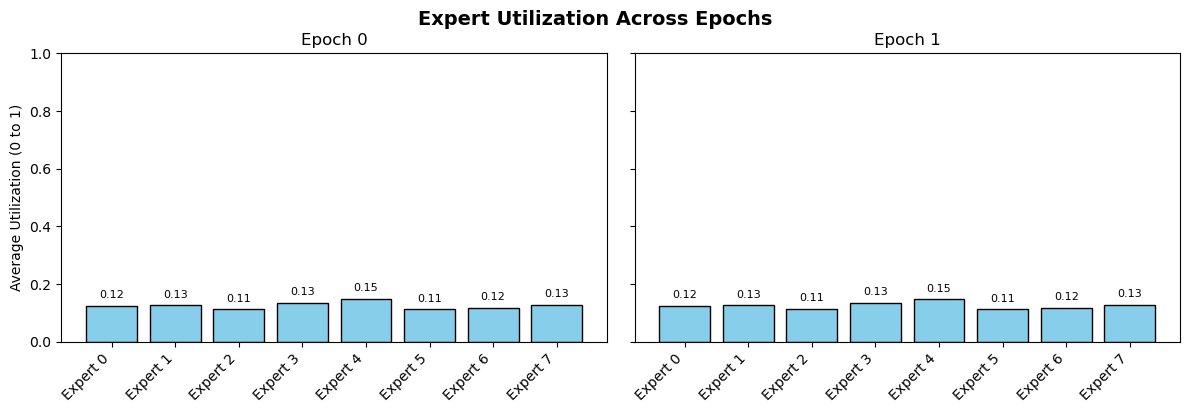

In [14]:
visualization.plot_utilization_histogram(
    epochs_to_plot=[0, 1], 
    utilization_data=expert_utilization_history
)

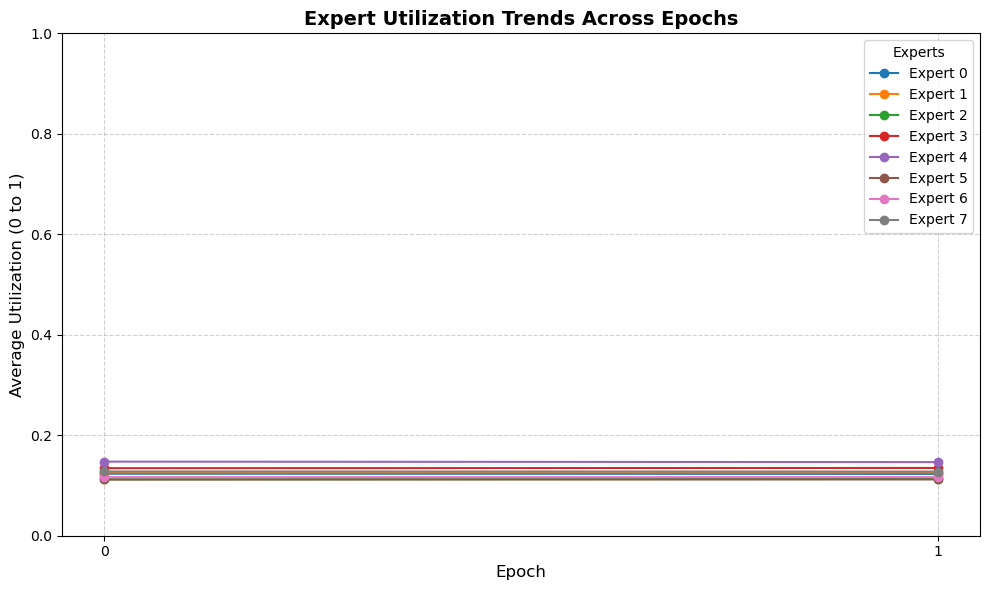

In [15]:
visualization.plot_utilization_trends(
    utilization_data=expert_utilization_history
)

## 4. Evaluation phase

### 4.1 Set-up

In [16]:
moe.eval()

# Access model parameters and nodes
for name, param in moe.named_parameters():
    print(name, param.shape)
print(get_graph_node_names(moe))

gate.l_sparse.weight torch.Size([8, 784])
gate.l_sparse.bias torch.Size([8])
gate.l_noise.weight torch.Size([8, 784])
gate.l_noise.bias torch.Size([8])
experts.0.l_1.weight torch.Size([25, 784])
experts.0.l_1.bias torch.Size([25])
experts.0.output.weight torch.Size([10, 25])
experts.0.output.bias torch.Size([10])
experts.1.l_1.weight torch.Size([25, 784])
experts.1.l_1.bias torch.Size([25])
experts.1.output.weight torch.Size([10, 25])
experts.1.output.bias torch.Size([10])
experts.2.l_1.weight torch.Size([25, 784])
experts.2.l_1.bias torch.Size([25])
experts.2.output.weight torch.Size([10, 25])
experts.2.output.bias torch.Size([10])
experts.3.l_1.weight torch.Size([25, 784])
experts.3.l_1.bias torch.Size([25])
experts.3.output.weight torch.Size([10, 25])
experts.3.output.bias torch.Size([10])
experts.4.l_1.weight torch.Size([25, 784])
experts.4.l_1.bias torch.Size([25])
experts.4.output.weight torch.Size([10, 25])
experts.4.output.bias torch.Size([10])
experts.5.l_1.weight torch.Size([

In [17]:
# For getting the probability distribution for experts
return_nodes = {
    "gate.softmax" : "probs"
}

# Geeting the gating network
moe_gating = create_feature_extractor(moe, return_nodes=return_nodes)
moe_gating.eval()
moe_gating = moe_gating.to(DEVICE)

In [40]:
from scripts.data import create_class_dataloaders

class_num = 10
test_loaders = create_class_dataloaders(test_dataset, class_num=class_num)

In [39]:
print(class_num)

256


### 4.2 Evaluation

In [19]:
from scripts.eval import calculate_accuracy, eval_loop

In [41]:
# Initialize lists to store a single value (the statistic) for each digit (0-9)
final_test_loss = [None] * class_num
final_test_accuracy = [None] * class_num
expert_probs_per_digit = [None] * class_num
print(expert_probs_per_digit)
# Iterate through the 10 data loaders (one for each digit)
for idx, loader in enumerate(test_loaders):
    metrics = eval_loop(
        loader=loader,
        model=moe,
        model_gating=moe_gating,
        loss_function=loss_function,
        device=DEVICE
    )

    final_test_loss[idx] = metrics.get("loss")
    final_test_accuracy[idx] = metrics.get("accuracy")
    expert_probs_per_digit[idx] = metrics.get("mean_expert_probs")

[None, None, None, None, None, None, None, None, None, None]


In [42]:
for i in expert_probs_per_digit:
    print(i)

[0.1250816136598587, 0.12614241242408752, 0.08789996057748795, 0.15417130291461945, 0.13635315001010895, 0.1205563023686409, 0.10626707226037979, 0.14352811872959137]
[0.12390965223312378, 0.1211974024772644, 0.13688614964485168, 0.11718697845935822, 0.1455511897802353, 0.11239136755466461, 0.12287529557943344, 0.12000198662281036]
[0.12327075749635696, 0.12266584485769272, 0.1086626872420311, 0.1325148046016693, 0.1223689541220665, 0.11705023795366287, 0.12734617292881012, 0.14612053334712982]
[0.11903819441795349, 0.11938288062810898, 0.11351466923952103, 0.1369571089744568, 0.1458691656589508, 0.10952599346637726, 0.12733764946460724, 0.128374382853508]
[0.11997289955615997, 0.13360783457756042, 0.11550147086381912, 0.13738159835338593, 0.1454857587814331, 0.10950019210577011, 0.11983782052993774, 0.11871247738599777]
[0.13118362426757812, 0.13027361035346985, 0.11059224605560303, 0.1292070895433426, 0.1490359604358673, 0.10669966787099838, 0.11473003774881363, 0.12827782332897186]


### 4.3 Plots

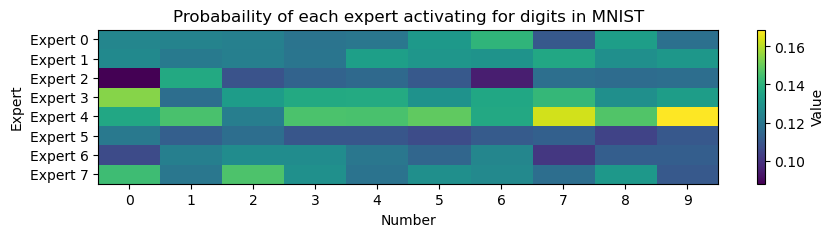

In [43]:
expert_probs_per_digit = np.array(expert_probs_per_digit).squeeze().T
visualization.plot_expert_activation(expert_probs_per_digit, expert_num=EXPERT_NUM)